In [12]:
#Use supervised learning algorithms to make predictions of credit card fraud. V1-V28
#are anonymised features representing various transaction attributes (e.g., time, location, etc.).
#Amount means the transaction amount. Class (1) means fraudulent while (0) means not.

In [13]:
import pandas as pd

card = pd.read_csv("creditcard_sample.csv")

In [14]:
card

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,437378,0.420468,-0.070194,-0.569266,0.191673,-0.009607,0.426903,-0.356728,0.096143,0.077806,...,0.134969,0.070433,0.047770,-0.851622,0.102876,-0.375436,0.820807,0.665983,8633.18,1
1,504222,-0.238944,0.250929,-0.374408,0.152938,-0.105008,-0.039028,-0.293004,0.133771,-0.591631,...,0.192405,0.289441,-0.255187,-0.817462,0.308284,1.582688,0.574425,0.478489,12299.55,1
2,4794,-0.117796,-0.147961,2.130455,-0.325762,0.325616,0.271351,0.772625,-0.244342,1.240012,...,-0.271739,-0.404654,-0.121235,0.857659,0.541920,0.756534,-0.238177,-0.403038,5215.87,0
3,388411,-0.855315,0.137014,-0.628116,0.613733,-0.643573,-0.664283,-0.880040,0.466586,-1.045508,...,0.405505,0.167560,0.446262,-0.205976,0.492582,0.658619,1.609128,-0.025592,19282.98,1
4,424512,0.257686,0.035247,-0.203112,0.506745,-0.242235,-0.192608,-0.289297,0.044488,-0.396122,...,0.162191,0.165912,-0.181999,0.331451,1.043095,0.029799,0.643273,0.736723,19114.27,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1132,255406,1.855999,-0.310876,-0.209382,-0.118529,0.639078,-0.516462,0.869192,-0.285096,0.392856,...,0.009254,0.937428,-0.255676,-0.109114,1.407697,-0.426385,-0.303074,-0.298602,5403.78,0
1133,323151,1.485939,-0.688203,0.355249,-0.673669,-0.063465,0.279385,0.156722,-0.136156,0.421310,...,-0.105240,0.233791,0.068495,1.365520,0.065882,-0.488060,-0.186789,-0.088532,5532.78,1
1134,260656,-0.345470,-0.461236,1.340339,-0.922515,0.712406,0.068207,0.670845,-0.176251,0.112365,...,-0.310832,-1.170383,0.237265,-0.603856,0.119814,0.517640,-0.403629,0.036936,15867.38,0
1135,506979,-0.378111,0.267849,-0.837971,0.761726,-0.428241,0.168917,-0.661238,0.405648,-0.645272,...,0.301869,0.439630,-0.035664,-0.625653,0.045050,0.250439,-0.135510,-0.671117,15585.06,1


In [15]:
#Drop the non-relevant column id.

card = card.drop(columns=['id'])

In [16]:
#First, use Logistic Regression.

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = card.drop(columns=['Class'])
y = card['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

logit = LogisticRegression(class_weight='balanced', max_iter=10000) #If the maximum number of iterations is small, the results may fail to converge.
logit.fit(X_train, y_train)

y_pred = logit.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       115
           1       0.96      0.96      0.96       113

    accuracy                           0.96       228
   macro avg       0.96      0.96      0.96       228
weighted avg       0.96      0.96      0.96       228



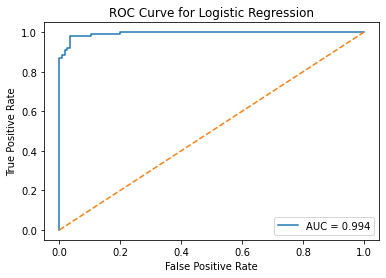

In [58]:
#Plot the ROC curve to investigate the trade-off between True Positive Rate and False Positive Rate

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = logit.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.show()

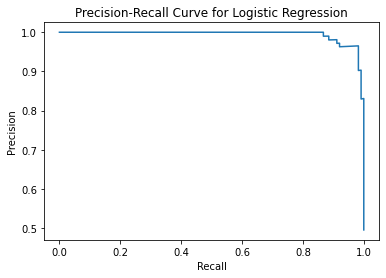

In [59]:
#Plot the Precision-Recall Curve. High recall means more fraud is caught, and high precision means fewer false alarms.

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Logistic Regression")
plt.show()

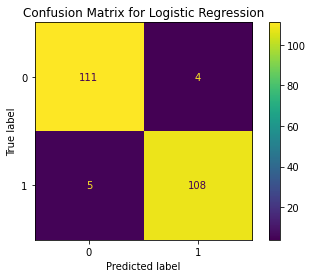

In [60]:
#Plot the Confusion Matrix. 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = logit.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

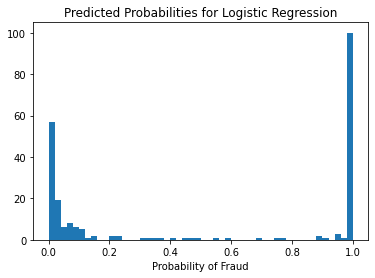

In [61]:
#Plot the predicted probability distribution.

plt.hist(y_prob, bins=50)
plt.title("Predicted Probabilities for Logistic Regression")
plt.xlabel("Probability of Fraud")
plt.show()

In [62]:
#Predict the class of a new data point.

import pandas as pd

new_data = pd.DataFrame(
    [[0.1, -0.2, 0.3, 0.15, 1.2, -0.8, 0.95, -0.77, 0.6, -1.25, 1.95, 0.3,
      -0.53, 0.4, 0.65, -0.77, 0.83, 0.92, -0.46, -1.77, 0.82, 0.01, 0.96,
      -0.59, 1.72, -1.8, -0.06, -1.6, 3758.03]],
    columns=X.columns
)

prediction_1 = logit.predict(new_data)
print(prediction_1) #It is fraudulent.

[1]


In [63]:
#Now, use Random Forest.

In [64]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 100, #100 decision trees
    class_weight = 'balanced',
    random_state = 42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       115
           1       0.97      0.94      0.95       113

    accuracy                           0.96       228
   macro avg       0.96      0.96      0.96       228
weighted avg       0.96      0.96      0.96       228



In [65]:
#Find the feature importance (top 10).

import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(10))

V10    0.154509
V14    0.135686
V4     0.124622
V12    0.115517
V11    0.100644
V7     0.061448
V17    0.059607
V16    0.044746
V3     0.031493
V2     0.021899
dtype: float64


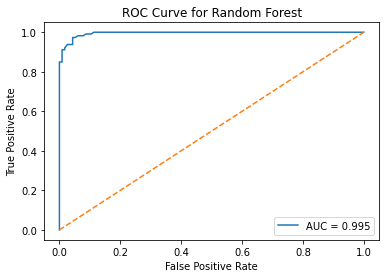

In [66]:
#Plot the ROC curve.

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Random Forest")
plt.legend()
plt.show()

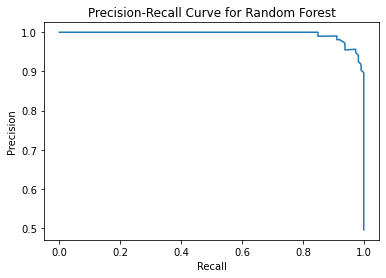

In [67]:
#Plot the Precision-Recall Curve.

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Random Forest")
plt.show()

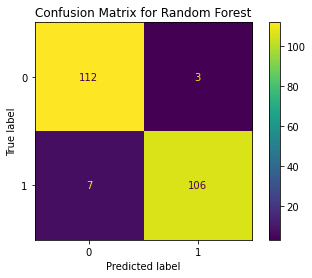

In [68]:
#Plot the Confusion Matrix. 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix for Random Forest")
plt.show()

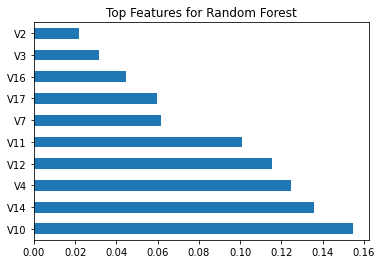

In [69]:
#Plot top 10 feature importance.

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Features for Random Forest")
plt.show()

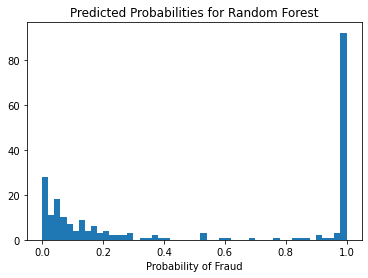

In [70]:
#Plot the predicted probability distribution.

plt.hist(y_prob, bins=50)
plt.title("Predicted Probabilities for Random Forest")
plt.xlabel("Probability of Fraud")
plt.show()

In [71]:
#Predict the class of a new data point.

import pandas as pd

new_data = pd.DataFrame(
    [[0.1, -0.2, 0.3, 0.15, 1.2, -0.8, 0.95, -0.77, 0.6, -1.25, 1.95, 0.3,
      -0.53, 0.4, 0.65, -0.77, 0.83, 0.92, -0.46, -1.77, 0.82, 0.01, 0.96,
      -0.59, 1.72, -1.8, -0.06, -1.6, 3758.03]],
    columns=X.columns
)

prediction_2 = rf.predict(new_data)
print(prediction_2) #It is fraudulent.

[1]


In [72]:
#Find an optimal threshold for the Random Forest model (default value is 0.5, also true for the logit model).

In [73]:
y_prob = rf.predict_proba(X_test)[:, 1]

In [74]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

Best threshold: 0.32
Best F1: 0.9649122806517583


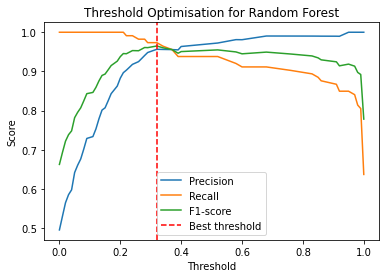

In [75]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1-score")

plt.axvline(best_threshold, color='red', linestyle='--', label="Best threshold")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimisation for Random Forest")
plt.legend()
plt.show()

In [76]:
y_pred_opt = (y_prob >= best_threshold).astype(int)

In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       115
           1       0.96      0.97      0.96       113

    accuracy                           0.96       228
   macro avg       0.96      0.96      0.96       228
weighted avg       0.97      0.96      0.96       228

